# SFR Fly Mean-Reversion — 4. PCA residual

**Formulation: the fly's deviation from a fitted factor curve.**

Fit a rolling PCA to the 16-slot strip, reconstruct each date's cross-section
from its `k` leading factors, and take the residual. The fly's signal is the
same weighted sum of its legs' residuals as its level is of its legs' rates —
so the units stay bp and the object stays the traded package.

The economic claim is different from a z-score. A z-score asks "is this fly
high relative to its own history?"; a PCA residual asks "is this fly high
relative to what the *rest of the curve* is doing today?". The second is
cross-sectionally hedged, so it should be far less exposed to the regime drift
that dominates the level (the OU notebook measured a median `mu` spread across
regimes of several bp against a 1.5bp round trip).

One eigendecomposition per **date**, not per fly — a per-structure rolling PCA
would repeat the identical decomposition once for each of the 26 structures.
Loadings are sign-aligned to the previous window so an eigenvector flip does
not print as a spurious residual jump.

In [1]:
CONFIG = dict(
    primary_structure="3m",
    primary_window="liquid16",
    long_window="front8",
    cost_bp=1.5,
    n_packages=100,
    pca_windows=(126, 261, 500),
    ks=(2, 3, 4),
    on=("levels", "changes"),
    z_window=120,
    entry_zs=(1.5, 2.0, 2.5),
    exits=("z0", "half", "t10"),
    directions=("fade", "momentum"),
    max_hold=30,
    lag=1,
)
CONFIG

{'primary_structure': '3m',
 'primary_window': 'liquid16',
 'long_window': 'front8',
 'cost_bp': 1.5,
 'n_packages': 100,
 'pca_windows': (126, 261, 500),
 'ks': (2, 3, 4),
 'on': ('levels', 'changes'),
 'z_window': 120,
 'entry_zs': (1.5, 2.0, 2.5),
 'exits': ('z0', 'half', 't10'),
 'directions': ('fade', 'momentum'),
 'max_hold': 30,
 'lag': 1}

In [2]:
import sys
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from RVUtils.MeanRev import MRConfig
from RVUtils.MeanRev.signals import pca_residual_signal, zscore_signal
from RVUtils.mean_reversion import adf_pvalue, half_life, rolling_zscore
from sfr_fly_meanrev_common import (
    load_lab, per_slot_table, run_family,
)

pd.set_option("display.width", 230)
pd.set_option("display.max_columns", 60)

BASE = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=CONFIG["cost_bp"],
                max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])
lab = load_lab(CONFIG["primary_structure"], CONFIG["primary_window"])
levels, slot_panel, st = lab["levels"], lab["slot_panel"], lab["struct"]
print(f"{levels.shape[1]} flies, {levels.shape[0]} sessions; "
      f"strip panel {slot_panel.shape}")

34 flies, 1150 sessions; strip panel (1150, 16)


## 1. How much of the strip do 1-4 factors explain?

If three factors explain essentially everything, the residual is measurement
noise and there is nothing to trade. If they leave a persistent structured
remainder, that remainder is where a fly lives.

In [3]:
X = slot_panel.dropna(axis=1, how="all").dropna()
for tag, M in (("levels", X.to_numpy()), ("changes", X.diff().dropna().to_numpy())):
    C = np.cov(M - M.mean(axis=0), rowvar=False)
    ev = np.sort(np.linalg.eigvalsh(C))[::-1]
    ev = ev / ev.sum()
    print(f"  {tag:8s}: explained variance by factor "
          f"{np.round(ev[:6] * 100, 2)}  cumulative "
          f"{np.round(np.cumsum(ev[:6]) * 100, 3)}")

  levels  : explained variance by factor [8.348e+01 1.171e+01 4.550e+00 2.200e-01 3.000e-02 1.000e-02]  cumulative [83.477 95.182 99.735 99.952 99.98  99.993]
  changes : explained variance by factor [82.81 11.67  4.25  0.87  0.22  0.09]  cumulative [82.806 94.472 98.722 99.588 99.812 99.901]


## 2. The residual series

Built once at the middle grid setting so its properties can be inspected
before anything is traded.

In [4]:
resid = pca_residual_signal(slot_panel, st, window=261, k=3, on="levels")
resid = resid.reindex(index=levels.index, columns=levels.columns)
print(f"residual panel {resid.shape}, non-NaN {resid.notna().to_numpy().mean():.1%}")
rows = []
for c in resid.columns:
    s = resid[c].dropna()
    if len(s) < 250:
        continue
    rows.append({"key": c, "sd_bp": s.std(), "hl": half_life(s),
                 "adf_p": adf_pvalue(s),
                 "corr_with_level": float(levels[c].corr(resid[c]))})
rs = pd.DataFrame(rows)
print(rs.describe().round(3).to_string())
print(f"\nstationary at 10%: {int((rs['adf_p'] < 0.10).sum())}/{len(rs)} keys")
print(f"median |corr| between the PCA residual and the raw fly level: "
      f"{rs['corr_with_level'].abs().median():.3f}")
print("  (a residual that is ~the level again has hedged nothing)")

residual panel (1150, 34), non-NaN 22.5%


        sd_bp      hl   adf_p  corr_with_level
count  16.000  16.000  16.000           16.000
mean    1.596   7.420   0.067            0.260
std     1.060   5.670   0.127            0.359
min     0.428   0.872   0.000           -0.472
25%     0.578   2.332   0.000           -0.020
50%     1.253   6.502   0.003            0.301
75%     2.696  11.026   0.093            0.409
max     3.138  20.236   0.493            0.896

stationary at 10%: 12/16 keys
median |corr| between the PCA residual and the raw fly level: 0.340
  (a residual that is ~the level again has hedged nothing)


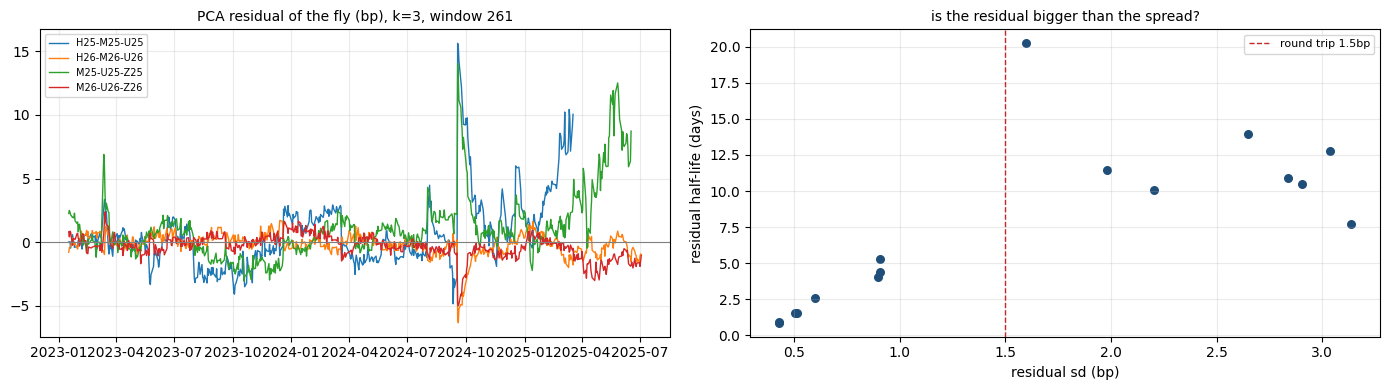

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pick = [c for c in resid.columns if resid[c].notna().sum() > 500][:4]
for c in pick:
    axes[0].plot(resid.index, resid[c].to_numpy(), lw=1.0, label=c)
axes[0].axhline(0, color="grey", lw=0.8)
axes[0].set_title("PCA residual of the fly (bp), k=3, window 261", fontsize=10)
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.25)
axes[1].scatter(rs["sd_bp"], rs["hl"], s=30, color="#1f4e79")
axes[1].set_xlabel("residual sd (bp)")
axes[1].set_ylabel("residual half-life (days)")
axes[1].axvline(CONFIG["cost_bp"], color="#c62828", ls="--", lw=1.0,
                label=f"round trip {CONFIG['cost_bp']}bp")
axes[1].set_title("is the residual bigger than the spread?", fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 3. Backtest — z-scored PCA residual


### GRID  (34 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/324 configs


  50/324 configs


  75/324 configs


  100/324 configs


...

  225/324 configs


  250/324 configs


  275/324 configs


  300/324 configs


  324 configs | median -251.00bp | IQR [-395.69, -161.81] | 0% net-positive | best -27.25bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 pca_window  k      on  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
        500  2  levels      2.5         z0  momentum        53     0.151      -0.514        -27.25       -68125.0  -0.774     -46.00
        500  2  levels      2.5       half  momentum        55     0.145      -0.686        -37.75       -94375.0  -1.149     -49.50
        500  3  levels      2.5         z0  momentum        52     0.154      -0.880        -45.75      -114375.0  -1.430     -54.00
        261  3  levels      2.5       half      fade        75     0.160      -0.673        -50.50      -126250.0  -0.958     -86.50
        261  4  levels      2.5       half      fade        79     0.165      -0.661        -52.25      -130625.0  -0.937     -82.75
        500  3 changes      2.5         

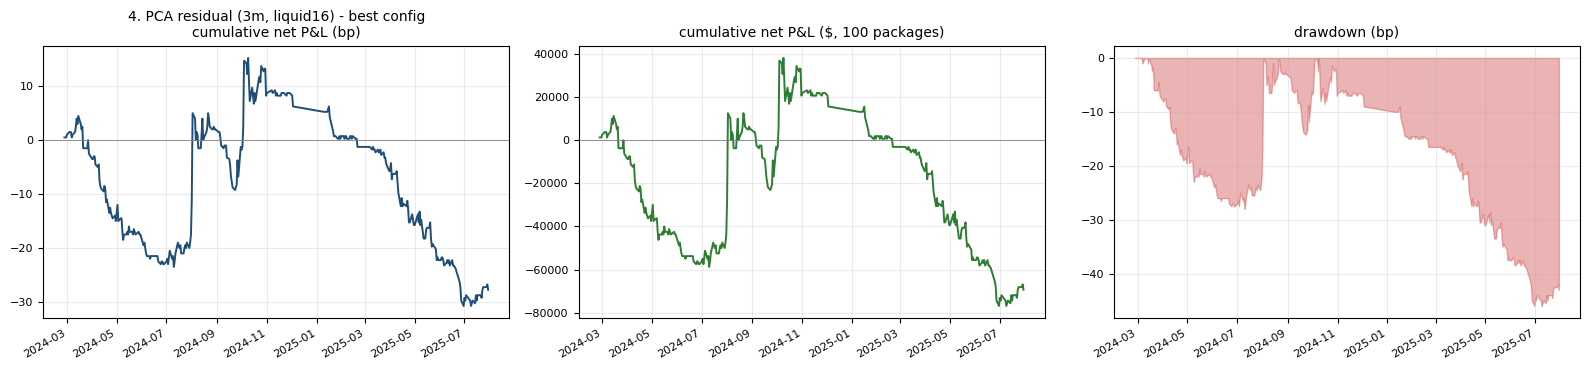


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
H26-M26-U26   -1  2024-02-23 2024-02-26 2024-03-21    18 -3.014     -0.50       -1.0      0.50      1.5   -1.00  -2500.0 mean_reversion
M26-U26-Z26   -1  2024-02-26 2024-02-27 2024-04-10    30 -2.848      0.50       -1.0      1.50      1.5    0.00      0.0       max_hold
Z24-H25-M25    1  2024-03-05 2024-03-06 2024-03-21    11  2.693     -5.50       -5.0      0.50      1.5   -1.00  -2500.0 mean_reversion
H27-M27-U27   -1  2024-03-05 2024-03-06 2024-03-28    16 -2.564     -0.50       -1.0      0.50      1.5   -1.00  -2500.0 mean_reversion
Z26-H27-M27   -1  2024-03-07 2024-03-08 2024-04-22    30 -2.681     -0.50       -1.0      0.50      1.5   -1.00  -2500.0       max_hold
M25-U25-Z25    1  2024-03-14 2024-03-15 2024-03-21     4  3.201     -5.50       -5.5      0.00      1.5   -1.50  -3750.0 mean_reversion
H25-M25-U25   -1  202


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5        53            52.2         -27.2      -0.514     0.151  -0.774      -46.0      20.1          False             False
         belly       1            0.5        53           218.0         191.5       3.613     0.547   0.581     -270.5      20.1           True              True
belly_vs_front       2            1.0        53            86.2          33.2       0.627     0.283   0.689      -34.0      20.1           True              True
 belly_vs_back       2            1.0        53           -34.0         -87.0      -1.642     0.226  -2.457      -91.0      20.1          False             False
  -> SHADOWED - a simpler instrument beats the fly on net bp
4. PCA residual (3m, liquid16) - MEDIAN config (the anti

In [6]:
def pca_sig(L, pca_window, k, on):
    r = pca_residual_signal(slot_panel, st, window=pca_window, k=k, on=on)
    r = r.reindex(index=L.index, columns=L.columns)
    return r.apply(lambda s: rolling_zscore(s, CONFIG["z_window"],
                                            min_periods=40, ddof=0))


GRID = {"pca_window": CONFIG["pca_windows"], "k": CONFIG["ks"], "on": CONFIG["on"],
        "entry_z": CONFIG["entry_zs"], "exit_style": CONFIG["exits"],
        "direction": CONFIG["directions"]}
PARAMS = ["pca_window", "k", "on", "entry_z", "exit_style", "direction"]
out = run_family("4. PCA residual (3m, liquid16)", lab=lab, signal_fn=pca_sig,
                 grid_spec=GRID, params=PARAMS, base=BASE, cls="pca",
                 note="rolling strip PCA; fly residual z-scored")

## 4. Raw residual as the signal (no second standardisation)

The residual is already in bp and already centred, so z-scoring it a second
time is a modelling choice worth testing rather than assuming.


### GRID  (34 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/48 configs


  48 configs | median -166.12bp | IQR [-316.25, -79.94] | 0% net-positive | best -16.00bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 pca_window  k  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
        500  3      4.0         z0  momentum        34     0.324      -0.471        -16.00       -40000.0  -0.311     -49.50
        261  4      4.0         z0      fade        37     0.432      -0.473        -17.50       -43750.0  -0.290     -55.25
        261  4      2.0         z0      fade       116     0.431      -0.194        -22.50       -56250.0  -0.234     -89.25
        500  4      4.0         z0      fade        22     0.364      -1.432        -31.50       -78750.0  -0.964     -39.50
        500  4      4.0         z0  momentum        22     0.227      -1.568        -34.50       -86250.0  -1.056     -47.00
        500  3      2.0         z0  momentum        71     0.296      -0.588        -41.75

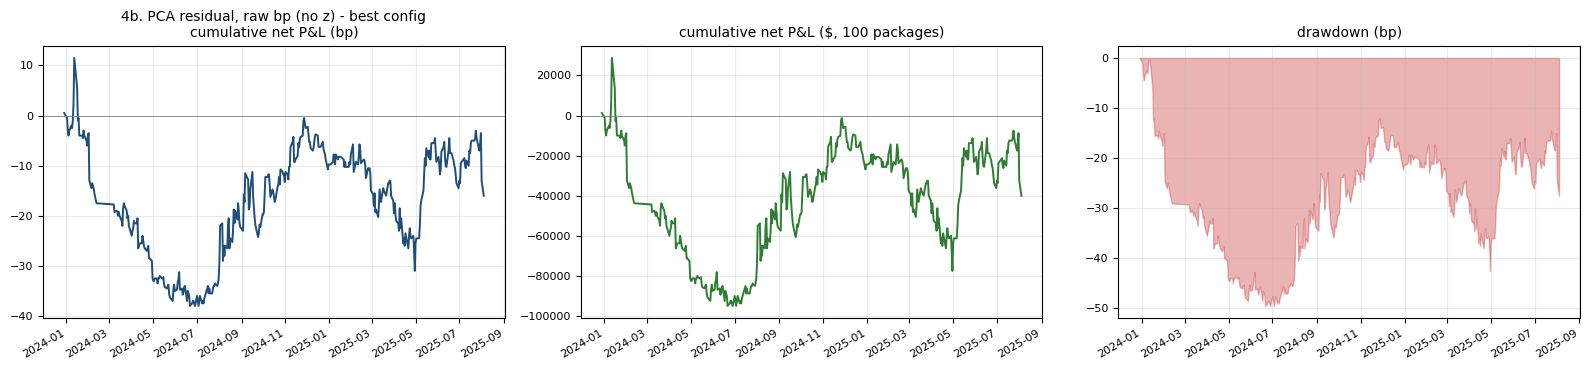


  trade log (first rows):
        key  dir signal_date      entry       exit  days    z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
H24-M24-U24   -1  2023-12-27 2023-12-28 2024-01-24    17  -8.259     -5.00      -1.00     -4.00      1.5   -5.50 -13750.0 mean_reversion
M24-U24-Z24   -1  2023-12-27 2023-12-28 2024-02-12    30  -8.826     -5.00      -2.50     -2.50      1.5   -4.00 -10000.0       max_hold
H24-M24-U24   -1  2024-01-31 2024-02-01 2024-02-06     3  -4.622     -5.00       1.50     -6.50      1.5   -8.00 -20000.0 mean_reversion
H24-M24-U24   -1  2024-03-05 2024-03-06 2024-03-19     9  -4.162      7.50       7.50     -0.00      1.5   -1.50  -3750.0       max_hold
M24-U24-Z24   -1  2024-03-06 2024-03-07 2024-04-19    30  -4.520      0.00       2.50     -2.50      1.5   -4.00 -10000.0       max_hold
U24-Z24-H25   -1  2024-03-15 2024-03-18 2024-04-30    30  -4.468     -3.00       2.50     -5.50      1.5   -7.00 -17500.0       max_hold
M24-U24-Z24   


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5        34            35.0         -16.0      -0.471     0.324  -0.311      -49.5      26.2          False             False
         belly       1            0.5        34           145.5         128.5       3.779     0.500   0.495     -234.5      26.2           True              True
belly_vs_front       2            1.0        34            52.0          18.0       0.529     0.500   0.183      -85.3      26.2           True              True
 belly_vs_back       2            1.0        34           -17.0         -51.0      -1.500     0.412  -0.752     -116.5      26.2          False             False
  -> SHADOWED - a simpler instrument beats the fly on net bp
4b. PCA residual, raw bp (no z) - MEDIAN config (the ant

In [7]:
def pca_raw(L, pca_window, k):
    r = pca_residual_signal(slot_panel, st, window=pca_window, k=k, on="levels")
    return r.reindex(index=L.index, columns=L.columns)


out_raw = run_family(
    "4b. PCA residual, raw bp (no z)", lab=lab, signal_fn=pca_raw,
    grid_spec={"pca_window": (261, 500), "k": (3, 4),
               "entry_z": (1.0, 2.0, 4.0),        # here entry_z is in BP
               "exit_style": ("z0", "t10"), "direction": ("fade", "momentum")},
    params=["pca_window", "k", "entry_z", "exit_style", "direction"],
    base=BASE, cls="pca",
    note="entry threshold in bp of residual, not sigmas")

## 5. Per-slot and long window

In [8]:
per = per_slot_table(out["result"], lab)
if not per.empty:
    print(per.round(3).to_string(index=False))

 slot           cm  n   hit  avg_net_bp  total_net_bp  total_gross_bp  avg_hold  total_net_usd
  2.0       SFR123  3 0.667       9.750         29.25           33.75    21.000        73125.0
  3.0       SFR234  4 0.500       2.625         10.50           16.50    24.000        26250.0
  4.0       SFR345  4 0.500      -1.125         -4.50            1.50    23.000       -11250.0
  5.0       SFR456  5 0.000      -1.400         -7.00            0.50    25.200       -17500.0
  6.0       SFR567  4 0.250      -1.750         -7.00           -1.00    21.250       -17500.0
  7.0       SFR678  4 0.000      -1.250         -5.00            1.00    17.750       -12500.0
  8.0       SFR789  3 0.333      -0.667         -2.00            2.50    30.000        -5000.0
  9.0   SFR-8-9-10  4 0.000      -1.625         -6.50           -0.50    21.000       -16250.0
 10.0  SFR-9-10-11  3 0.000      -1.167         -3.50            1.00    19.333        -8750.0
 11.0 SFR-10-11-12  6 0.000      -1.333         -8


### GRID  (42 keys, 1907 sessions, window=front8: slots 1-8 are continuously liquid from 2019; buys ZIRP+hiking)


  25/36 configs


  36 configs | median -232.62bp | IQR [-286.06, -146.75] | 0% net-positive | best -28.75bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 pca_window  k     on  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
        261  3 levels      2.5       half      fade        93     0.312      -0.309        -28.75       -71875.0  -0.266     -52.25
        500  3 levels      2.5       half      fade        79     0.329      -0.503        -39.75       -99375.0  -0.358     -62.00
        261  3 levels      2.5         z0      fade        98     0.367      -0.515        -50.50      -126250.0  -0.405     -72.75
        500  3 levels      2.5         z0      fade        80     0.325      -0.944        -75.50      -188750.0  -0.616     -78.75
        500  3 levels      2.5        t10      fade       100     0.270      -1.040       -104.00      -260000.0  -1.257    -106.25
        261  3 levels      2.0       half      

4c. PCA residual (3m, front8, 2019+) - best config  |  fade|z2.5|half|hold30|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  long history
  trades    93   skipped    1   hit 31%   avg -0.309bp   avg hold 15.6d
  total     -28.75bp   $      -71,875   gross +110.75bp
  daily-MTM Sharpe -0.27   maxDD -52.25bp ($-130,625)   worst trade -15.75bp
  t(trade) -0.65   NW t(daily) -0.52   non-overlap SR +0.03   DSR p=0.001 over 36 trials


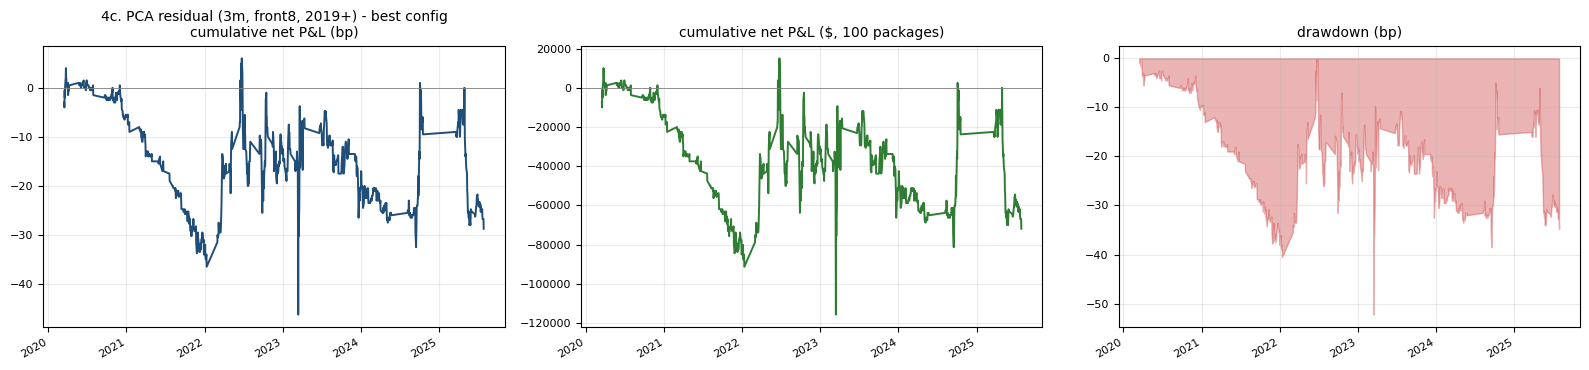


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
H21-M21-U21    1  2020-03-12 2020-03-13 2020-03-19     4 -4.021      1.50       3.00      1.50      1.5    0.00      0.0 take_profit
Z20-H21-M21   -1  2020-03-12 2020-03-13 2020-03-25     8  4.074      1.00       2.00     -1.00      1.5   -2.50  -6250.0 take_profit
M21-U21-Z21    1  2020-03-16 2020-03-17 2020-03-24     5 -4.124     -2.00       1.50      3.50      1.5    2.00   5000.0 take_profit
M20-U20-Z20   -1  2020-03-18 2020-03-19 2020-04-09    15  3.647     -2.00      -4.50      2.50      1.5    1.00   2500.0 take_profit
H21-M21-U21    1  2020-05-20 2020-05-21 2020-06-16    17 -2.663     -2.00      -1.00      1.00      1.5   -0.50  -1250.0 take_profit
U20-Z20-H21   -1  2020-06-17 2020-06-18 2020-07-30    29  2.549      0.50       0.50     -0.00      1.5   -1.50  -3750.0 take_profit
Z21-H22-M22    1  2020-09-16 2020-09-17 20

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0        98    18.602     0.367      -0.515        -50.50  -0.405
half        93    15.581     0.312      -0.309        -28.75  -0.266
band        93    15.581     0.312      -0.309        -28.75  -0.266
  t5       127     4.929     0.228      -1.197       -152.00  -2.516
 t10       103     9.728     0.233      -1.410       -145.25  -1.743
 t20        89    19.124     0.326      -0.096         -8.50  -0.073

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 93        110.75       1.191     0.548       276875.0
           0.5 93         64.25       0.691     0.419       160625.0
           1.0 93         17.75       0.191     0.355        44375.0
           1.5 93        -28.75      -0.309     0.312       -71875.0
           2.5 93       -121.75      -1.309     0.237      -304375.0
           4.0 93       -261.25      -2.809     0

4c. PCA residual (3m, front8, 2019+) - MEDIAN config (the anti-selection control)  |  momentum|z2.0|t10|hold30|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  trades   175   skipped    2   hit 17%   avg -1.316bp   avg hold 9.8d
  total    -230.25bp   $     -575,625   gross +32.25bp
  daily-MTM Sharpe -2.04   maxDD -247.50bp ($-618,750)   worst trade -12.00bp
  t(trade) -5.15   NW t(daily) -3.85   non-overlap SR -0.33   DSR p=0.000 over 36 trials

  LEAGUE ROW  4c. PCA residual (3m, front8, 2019+) / best-config: MARGINAL-maker-only  (taker -121.75bp, maker +110.75bp, DSR p=0.001)

  LEAGUE ROW  4c. PCA residual (3m, front8, 2019+) / median-config: MARGINAL-maker-only  (taker -405.25bp, maker +32.25bp, DSR p=0.000)


In [9]:
lab8 = load_lab(CONFIG["primary_structure"], CONFIG["long_window"])
st8, sp8 = lab8["struct"], lab8["slot_panel"]


def pca_sig8(L, pca_window, k, on):
    r = pca_residual_signal(sp8, st8, window=pca_window, k=k, on=on)
    r = r.reindex(index=L.index, columns=L.columns)
    return r.apply(lambda s: rolling_zscore(s, CONFIG["z_window"],
                                            min_periods=40, ddof=0))


out8 = run_family("4c. PCA residual (3m, front8, 2019+)", lab=lab8,
                  signal_fn=pca_sig8,
                  grid_spec={"pca_window": (261, 500), "k": (3,), "on": ("levels",),
                             "entry_z": CONFIG["entry_zs"],
                             "exit_style": CONFIG["exits"],
                             "direction": CONFIG["directions"]},
                  params=["pca_window", "k", "on", "entry_z", "exit_style",
                          "direction"],
                  base=BASE, cls="pca", note="long history")